# Sensitivity Analysis

## Baseline settings

In [16]:
import pandas as pd
import pulp

# -----------------------------
# 1) Baseline data definition
# -----------------------------
customers = [f"C{i+1}" for i in range(10)]
locations = [f"T{j+1}" for j in range(8)]

# Baseline economic parameters
r = 10.0
k = 5.0
f = 250.0

demands = {
    "C1": 65, "C2": 40, "C3": 55, "C4": 30, "C5": 75,
    "C6": 50, "C7": 60, "C8": 35, "C9": 45, "C10": 70,
}


alpha = {
    "C1":  {"T1": 0.9, "T2": 0.7, "T3": 0.2, "T4": 0.1, "T5": 0.0, "T6": 0.3, "T7": 0.6, "T8": 0.4},
    "C2":  {"T1": 0.4, "T2": 0.8, "T3": 0.1, "T4": 0.0, "T5": 0.6, "T6": 0.2, "T7": 0.3, "T8": 0.7},
    "C3":  {"T1": 0.2, "T2": 0.3, "T3": 0.9, "T4": 0.5, "T5": 0.1, "T6": 0.0, "T7": 0.6, "T8": 0.4},
    "C4":  {"T1": 0.1, "T2": 0.0, "T3": 0.4, "T4": 0.8, "T5": 0.9, "T6": 0.3, "T7": 0.5, "T8": 0.2},
    "C5":  {"T1": 0.7, "T2": 0.6, "T3": 0.3, "T4": 0.0, "T5": 0.4, "T6": 0.9, "T7": 0.1, "T8": 0.5},
    "C6":  {"T1": 0.5, "T2": 0.2, "T3": 0.1, "T4": 0.3, "T5": 0.6, "T6": 0.4, "T7": 0.8, "T8": 0.7},
    "C7":  {"T1": 0.3, "T2": 0.4, "T3": 0.0, "T4": 0.6, "T5": 0.2, "T6": 0.1, "T7": 0.9, "T8": 0.8},
    "C8":  {"T1": 0.6, "T2": 0.5, "T3": 0.7, "T4": 0.1, "T5": 0.3, "T6": 0.0, "T7": 0.2, "T8": 0.9},
    "C9":  {"T1": 0.2, "T2": 0.1, "T3": 0.6, "T4": 0.9, "T5": 0.4, "T6": 0.8, "T7": 0.0, "T8": 0.3},
    "C10": {"T1": 0.8, "T2": 0.3, "T3": 0.5, "T4": 0.2, "T5": 0.7, "T6": 0.1, "T7": 0.4, "T8": 0.6},
}

Method: SciPy optimize (fast)
Solve status: Stopped (STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT)
Elapsed time: 1.32 seconds
Pairs used (alpha>0): 72
MAE:  1.2997
RMSE: 2.2528
Max |error|: 7.8291

Recovered coordinates:


,node,type,x,y
0,C1,customer,0.023598,-0.926052
9,C10,customer,-0.446383,0.803609
1,C2,customer,1.133874,-0.918123
2,C3,customer,-1.842150,1.105805
3,C4,customer,-3.386751,1.036991
4,C5,customer,0.351719,1.076597
5,C6,customer,-1.157378,-1.126068
6,C7,customer,1.148965,2.184285
7,C8,customer,0.863277,1.398523
8,C9,customer,-2.936877,1.420005



Largest distance mismatches:


,customer,site,alpha,target_d,fitted_d,error,abs_error
18,C3,T5,0.1,10.000000,2.170857,-7.829143,7.829143
33,C5,T7,0.1,10.000000,3.825412,-6.174588,6.174588
37,C6,T3,0.1,10.000000,4.026882,-5.973118,5.973118
21,C4,T1,0.1,10.000000,4.423742,-5.576258,5.576258
32,C5,T6,0.9,1.111111,6.211828,5.100717,5.100717
53,C8,T4,0.1,10.000000,4.932884,-5.067116,5.067116
69,C10,T6,0.1,10.000000,5.140738,-4.859262,4.859262
48,C7,T7,0.9,1.111111,5.730346,4.619235,4.619235
58,C9,T2,0.1,10.000000,5.821581,-4.178419,4.178419
9,C2,T3,0.1,10.000000,6.110191,-3.889809,3.889809


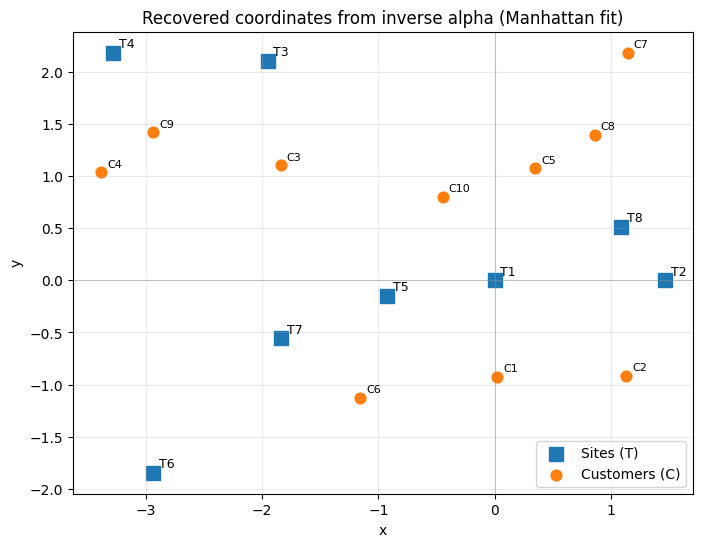

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp
import time

if "alpha" not in globals() or "customers" not in globals() or "locations" not in globals():
    raise ValueError("Please run the baseline cell first.")

# 1) Build inverse-alpha target distances (skip alpha == 0)
pairs = []
d_vals = []
for c in customers:
    for t in locations:
        a = float(alpha[c][t])
        if a > 0:
            pairs.append((c, t))
            d_vals.append(1.0 / a)

d_vals = np.array(d_vals, dtype=float)
if len(pairs) == 0:
    raise ValueError("No valid alpha>0 pairs found.")

# Index maps for vectorized computations
c_idx = {c: i for i, c in enumerate(customers)}
t_idx = {t: j for j, t in enumerate(locations)}
pair_ci = np.array([c_idx[c] for c, _ in pairs], dtype=int)
pair_tj = np.array([t_idx[t] for _, t in pairs], dtype=int)

# 2) Fast solver first: smooth L1 fitting via scipy.optimize (seconds-level)
#    Fallback: exact MILP with time limit if scipy is unavailable.
method_used = None
solve_status = None

cx = np.zeros(len(customers), dtype=float)
cy = np.zeros(len(customers), dtype=float)
tx = np.zeros(len(locations), dtype=float)
ty = np.zeros(len(locations), dtype=float)

start_time = time.time()

try:
    from scipy.optimize import minimize

    # Free variables:
    # cx[all], cy[all], tx[1:], ty[2:]
    # Anchors: T1=(0,0), T2_y=0, and T2_x >= 0 via bounds
    nC = len(customers)
    nT = len(locations)

    n_cx = nC
    n_cy = nC
    n_tx = nT - 1
    n_ty = max(0, nT - 2)

    def unpack(z):
        p = 0
        cx_ = z[p:p + n_cx]
        p += n_cx
        cy_ = z[p:p + n_cy]
        p += n_cy

        tx_ = np.zeros(nT)
        ty_ = np.zeros(nT)

        tx_[1:] = z[p:p + n_tx]
        p += n_tx

        if n_ty > 0:
            ty_[2:] = z[p:p + n_ty]

        return cx_, cy_, tx_, ty_

    def objective(z):
        cx_, cy_, tx_, ty_ = unpack(z)
        d_hat = np.abs(cx_[pair_ci] - tx_[pair_tj]) + np.abs(cy_[pair_ci] - ty_[pair_tj])
        r = d_hat - d_vals
        # Smooth |r| for stable gradient-based optimization
        return float(np.sum(np.sqrt(r * r + 1e-8)))

    # Bounds: keep coordinates in a compact box for stability
    B = 20.0
    bounds = []
    bounds += [(-B, B)] * n_cx
    bounds += [(-B, B)] * n_cy
    # tx[1] is T2_x and constrained nonnegative, others free in [-B, B]
    for k in range(n_tx):
        if k == 0:
            bounds.append((0.0, B))
        else:
            bounds.append((-B, B))
    bounds += [(-B, B)] * n_ty

    best = None
    # Multi-start to avoid poor local minima
    for seed in [0, 7, 21]:
        rng = np.random.default_rng(seed)
        z0 = rng.uniform(-2.0, 2.0, size=(n_cx + n_cy + n_tx + n_ty))
        if n_tx > 0:
            z0[n_cx + n_cy] = abs(z0[n_cx + n_cy])

        res_opt = minimize(
            objective,
            z0,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 600, "ftol": 1e-10},
        )

        if best is None or res_opt.fun < best.fun:
            best = res_opt

    cx, cy, tx, ty = unpack(best.x)
    method_used = "SciPy optimize (fast)"
    solve_status = "Optimal-like" if best.success else f"Stopped ({best.message})"

except Exception:
    # Fallback: exact MILP, but with strict time control.
    prob_inv = pulp.LpProblem("InverseAlpha_ManhattanEmbedding", pulp.LpMinimize)

    x_c = pulp.LpVariable.dicts("x_c", customers, lowBound=None, upBound=None, cat=pulp.LpContinuous)
    y_c = pulp.LpVariable.dicts("y_c", customers, lowBound=None, upBound=None, cat=pulp.LpContinuous)
    x_t = pulp.LpVariable.dicts("x_t", locations, lowBound=None, upBound=None, cat=pulp.LpContinuous)
    y_t = pulp.LpVariable.dicts("y_t", locations, lowBound=None, upBound=None, cat=pulp.LpContinuous)

    ux = pulp.LpVariable.dicts("ux", pairs, lowBound=0, cat=pulp.LpContinuous)
    uy = pulp.LpVariable.dicts("uy", pairs, lowBound=0, cat=pulp.LpContinuous)
    bx = pulp.LpVariable.dicts("bx", pairs, cat=pulp.LpBinary)
    by = pulp.LpVariable.dicts("by", pairs, cat=pulp.LpBinary)
    res = pulp.LpVariable.dicts("res", pairs, lowBound=0, cat=pulp.LpContinuous)

    B = 20.0
    M = 2.0 * B

    for c in customers:
        prob_inv += x_c[c] <= B
        prob_inv += x_c[c] >= -B
        prob_inv += y_c[c] <= B
        prob_inv += y_c[c] >= -B
    for t in locations:
        prob_inv += x_t[t] <= B
        prob_inv += x_t[t] >= -B
        prob_inv += y_t[t] <= B
        prob_inv += y_t[t] >= -B

    prob_inv += x_t[locations[0]] == 0
    prob_inv += y_t[locations[0]] == 0
    if len(locations) > 1:
        prob_inv += y_t[locations[1]] == 0
        prob_inv += x_t[locations[1]] >= 0

    for (c, t), d in zip(pairs, d_vals):
        dx = x_c[c] - x_t[t]
        dy = y_c[c] - y_t[t]

        prob_inv += ux[(c, t)] >= dx
        prob_inv += ux[(c, t)] >= -dx
        prob_inv += ux[(c, t)] <= dx + M * (1 - bx[(c, t)])
        prob_inv += ux[(c, t)] <= -dx + M * bx[(c, t)]

        prob_inv += uy[(c, t)] >= dy
        prob_inv += uy[(c, t)] >= -dy
        prob_inv += uy[(c, t)] <= dy + M * (1 - by[(c, t)])
        prob_inv += uy[(c, t)] <= -dy + M * by[(c, t)]

        prob_inv += res[(c, t)] >= (ux[(c, t)] + uy[(c, t)] - d)
        prob_inv += res[(c, t)] >= (d - (ux[(c, t)] + uy[(c, t)]))

    prob_inv += pulp.lpSum(res[(c, t)] for (c, t) in pairs)

    # Time-limited solve to prevent minute-level stalls
    prob_inv.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=20, gapRel=0.02))

    for c in customers:
        cx[c_idx[c]] = float(pulp.value(x_c[c]))
        cy[c_idx[c]] = float(pulp.value(y_c[c]))
    for t in locations:
        tx[t_idx[t]] = float(pulp.value(x_t[t]))
        ty[t_idx[t]] = float(pulp.value(y_t[t]))

    method_used = "CBC MILP fallback (20s limit)"
    solve_status = pulp.LpStatus[prob_inv.status]

elapsed = time.time() - start_time

# 3) Collect diagnostics
coords_df = pd.DataFrame(
    [{"node": c, "type": "customer", "x": cx[c_idx[c]], "y": cy[c_idx[c]]} for c in customers]
    + [{"node": t, "type": "site", "x": tx[t_idx[t]], "y": ty[t_idx[t]]} for t in locations]
)

d_hat = np.abs(cx[pair_ci] - tx[pair_tj]) + np.abs(cy[pair_ci] - ty[pair_tj])
err = d_hat - d_vals

fit_df = pd.DataFrame({
    "customer": [c for c, _ in pairs],
    "site": [t for _, t in pairs],
    "alpha": [float(alpha[c][t]) for c, t in pairs],
    "target_d": d_vals,
    "fitted_d": d_hat,
    "error": err,
    "abs_error": np.abs(err),
})

mae = float(fit_df["abs_error"].mean())
rmse = float(np.sqrt((fit_df["error"] ** 2).mean()))
max_abs = float(fit_df["abs_error"].max())

print(f"Method: {method_used}")
print(f"Solve status: {solve_status}")
print(f"Elapsed time: {elapsed:.2f} seconds")
print(f"Pairs used (alpha>0): {len(fit_df)}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Max |error|: {max_abs:.4f}")

print("\nRecovered coordinates:")
display(coords_df.sort_values(["type", "node"]))

print("\nLargest distance mismatches:")
display(fit_df.sort_values("abs_error", ascending=False).head(12))

# 4) Visualization
plt.figure(figsize=(8, 6))

cust_plot = coords_df[coords_df["type"] == "customer"]
site_plot = coords_df[coords_df["type"] == "site"]

plt.scatter(site_plot["x"], site_plot["y"], marker="s", s=90, label="Sites (T)")
plt.scatter(cust_plot["x"], cust_plot["y"], marker="o", s=60, label="Customers (C)")

for _, row in site_plot.iterrows():
    plt.text(row["x"] + 0.05, row["y"] + 0.05, row["node"], fontsize=9)
for _, row in cust_plot.iterrows():
    plt.text(row["x"] + 0.05, row["y"] + 0.05, row["node"], fontsize=8)

plt.title("Recovered coordinates from inverse alpha (Manhattan fit)")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, linewidth=0.6, color="gray", alpha=0.5)
plt.axvline(0, linewidth=0.6, color="gray", alpha=0.5)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [18]:
def solve_basic_model(r, k, f, demands, alpha, unavailable_customers=None):
    """Solve baseline/basic binary model and return structured results."""
    unavailable_customers = set(unavailable_customers or [])
    active_customers = [c for c in customers if c not in unavailable_customers]

    prob = pulp.LpProblem("Dumplings_Basic_Model", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("x", locations, cat=pulp.LpBinary)
    y = pulp.LpVariable.dicts("y", (active_customers, locations), cat=pulp.LpBinary)

    prob += (
        pulp.lpSum((r - k) * alpha[i][j] * demands[i] * y[i][j] for i in active_customers for j in locations)
        - pulp.lpSum(f * x[j] for j in locations)
    )

    for i in active_customers:
        prob += pulp.lpSum(y[i][j] for j in locations) <= 1

    for i in active_customers:
        for j in locations:
            prob += y[i][j] <= x[j]

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    objective = float(pulp.value(prob.objective))
    open_sites = [j for j in locations if pulp.value(x[j]) > 0.5]

    assign_rows = []
    for i in active_customers:
        assigned = None
        assigned_alpha = 0.0
        for j in locations:
            if pulp.value(y[i][j]) > 0.5:
                assigned = j
                assigned_alpha = float(alpha[i][j])
                break
        assign_rows.append({
            "customer": i,
            "assigned_site": assigned if assigned is not None else "unserved",
            "served": 1 if assigned is not None else 0,
            "coverage_alpha": assigned_alpha,
            "demand": demands[i],
            "weighted_coverage_contrib": demands[i] * assigned_alpha,
        })

    assignment_df = pd.DataFrame(assign_rows)
    served_count = int(assignment_df["served"].sum())
    total_demand = float(sum(demands[i] for i in active_customers))
    weighted_coverage = (
        float(assignment_df["weighted_coverage_contrib"].sum()) / total_demand
        if total_demand > 0
        else 0.0
    )

    summary = {
        "status": pulp.LpStatus[prob.status],
        "objective_profit": objective,
        "n_open_sites": len(open_sites),
        "open_sites": open_sites,
        "n_active_customers": len(active_customers),
        "n_served_customers": served_count,
        "service_coverage": weighted_coverage,
    }

    return summary, assignment_df, prob


# -----------------------------
# 2) Run baseline scenario
# -----------------------------
baseline_summary, baseline_assignment, baseline_prob = solve_basic_model(
    r=r,
    k=k,
    f=f,
    demands=demands,
    alpha=alpha,
    unavailable_customers=None,
)

print("=== Baseline scenario solved ===")
for key, value in baseline_summary.items():
    print(f"{key}: {value}")

print("\nBaseline assignment table:")
display(baseline_assignment)

=== Baseline scenario solved ===
status: Optimal
objective_profit: 928.0
n_open_sites: 2
open_sites: ['T1', 'T4']
n_active_customers: 10
n_served_customers: 10
service_coverage: 0.68

Baseline assignment table:


,customer,assigned_site,served,coverage_alpha,demand,weighted_coverage_contrib
0,C1,T1,1,0.9,65,58.5
1,C2,T1,1,0.4,40,16.0
2,C3,T4,1,0.5,55,27.5
3,C4,T4,1,0.8,30,24.0
4,C5,T1,1,0.7,75,52.5
5,C6,T1,1,0.5,50,25.0
6,C7,T4,1,0.6,60,36.0
7,C8,T1,1,0.6,35,21.0
8,C9,T4,1,0.9,45,40.5
9,C10,T1,1,0.8,70,56.0


## Sensitivity 1: Fixed Truck Cost f

,f,profit,n_open_sites,open_sites,service_coverage,changed_assignments_vs_baseline
0,150.0,1156.0,3,"T1, T4, T8",0.764762,4
1,175.0,1081.0,3,"T1, T4, T8",0.764762,4
2,200.0,1028.0,2,"T1, T4",0.680000,0
3,225.0,978.0,2,"T1, T4",0.680000,0
4,250.0,928.0,2,"T1, T4",0.680000,0
5,275.0,883.0,1,T8,0.551429,10
6,300.0,858.0,1,T8,0.551429,10
7,325.0,833.0,1,T8,0.551429,10
8,350.0,808.0,1,T8,0.551429,10
9,375.0,783.0,1,T8,0.551429,10



Threshold points (open-site count changed):


,f,n_open_sites,profit
2,200.0,2,1028.0
5,275.0,1,883.0


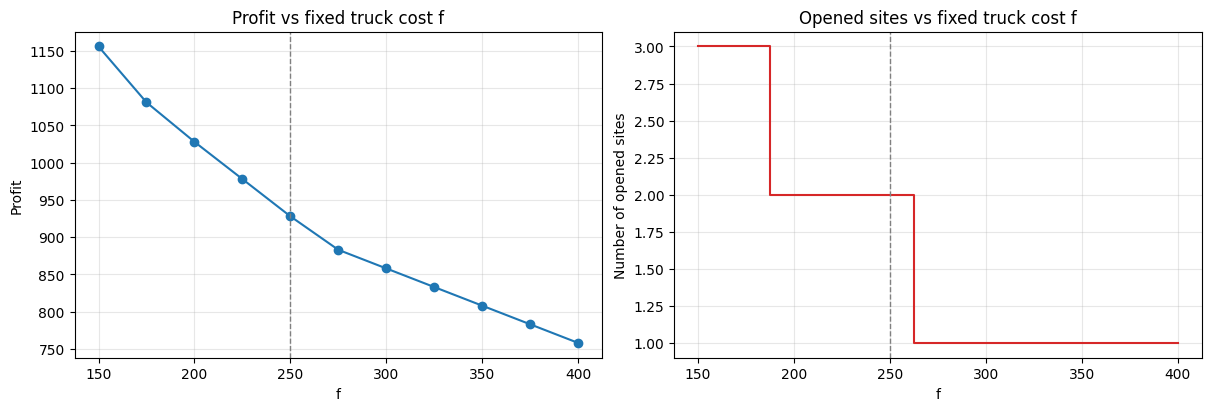

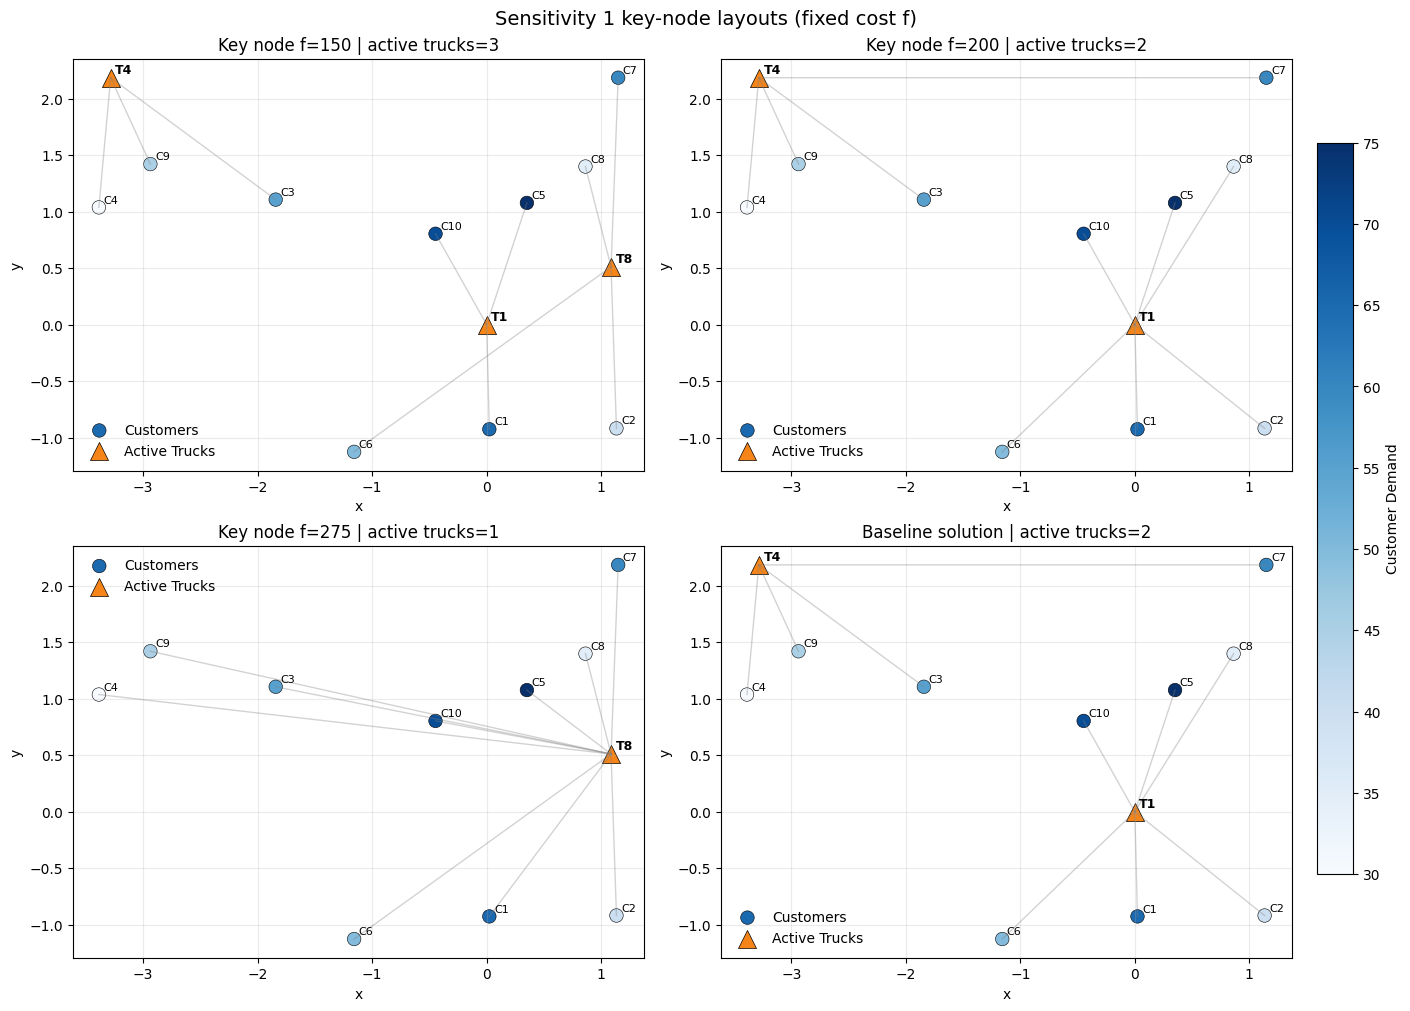

In [19]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

if "solve_basic_model" not in globals():
    raise ValueError("Please run the baseline cell first.")
if "coords_df" not in globals():
    raise ValueError("Please run the inverse-coordinate cell first to get coords_df.")
if "baseline_summary" not in globals() or "baseline_assignment" not in globals():
    raise ValueError("Please run the baseline-solution cell first.")

# Build baseline assignment map for change counting
base_map = baseline_assignment.set_index("customer")["assigned_site"].to_dict()

# Scan a cost range around baseline f=250
f_grid = np.arange(150, 401, 25)
records = []
solution_cache_f = {}

for f_test in f_grid:
    summary_tmp, assign_tmp, _ = solve_basic_model(
        r=r,
        k=k,
        f=float(f_test),
        demands=demands,
        alpha=alpha,
        unavailable_customers=None,
    )

    new_map = assign_tmp.set_index("customer")["assigned_site"].to_dict()
    changed_assignments = sum(1 for c in base_map if base_map[c] != new_map.get(c))

    records.append({
        "f": float(f_test),
        "profit": summary_tmp["objective_profit"],
        "n_open_sites": summary_tmp["n_open_sites"],
        "open_sites": ", ".join(summary_tmp["open_sites"]),
        "service_coverage": summary_tmp["service_coverage"],
        "changed_assignments_vs_baseline": int(changed_assignments),
    })
    solution_cache_f[float(f_test)] = (summary_tmp, assign_tmp)

df_f_sens = pd.DataFrame(records)
display(df_f_sens)

# Key threshold points where layout count changes
df_f_sens["delta_open_sites"] = df_f_sens["n_open_sites"].diff().fillna(0)
thresholds = df_f_sens[df_f_sens["delta_open_sites"] != 0][["f", "n_open_sites", "profit"]]

print("\nThreshold points (open-site count changed):")
if len(thresholds) == 0:
    print("No open-site count change in this f range.")
else:
    display(thresholds)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(df_f_sens["f"], df_f_sens["profit"], marker="o", color="#1f77b4")
axes[0].axvline(250, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Profit vs fixed truck cost f")
axes[0].set_xlabel("f")
axes[0].set_ylabel("Profit")
axes[0].grid(alpha=0.3)

axes[1].step(df_f_sens["f"], df_f_sens["n_open_sites"], where="mid", color="#d62728")
axes[1].axvline(250, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Opened sites vs fixed truck cost f")
axes[1].set_xlabel("f")
axes[1].set_ylabel("Number of opened sites")
axes[1].grid(alpha=0.3)

plt.show()

# Spatial plots on key f nodes (same style as previous section)
cust_coords = coords_df[coords_df["type"] == "customer"].set_index("node")[["x", "y"]].to_dict("index")
site_coords = coords_df[coords_df["type"] == "site"].set_index("node")[["x", "y"]].to_dict("index")

# Requirement update: remove f=250 key node, include f=150 key node, and add baseline panel
key_f_values = sorted(set([150.0] + thresholds["f"].astype(float).tolist()))
if len(key_f_values) == 0:
    key_f_values = [150.0]

# Keep subplot count compact for key nodes (baseline panel is added separately)
key_f_values = key_f_values[:6]
plot_cases = [{"mode": "f", "value": v} for v in key_f_values]
plot_cases.append({"mode": "baseline"})

demand_vals = [demands[c] for c in customers]
norm = Normalize(vmin=min(demand_vals), vmax=max(demand_vals))
sm = ScalarMappable(norm=norm, cmap="Blues")
sm.set_array([])

n_s = len(plot_cases)
ncols = 2
nrows = math.ceil(n_s / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, case in enumerate(plot_cases):
    ax = axes[idx]
    if case["mode"] == "baseline":
        summary_case = baseline_summary
        assign_case = baseline_assignment
        title_tag = "Baseline solution"
    else:
        f_node = float(case["value"] )
        summary_case, assign_case = solution_cache_f[f_node]
        title_tag = f"Key node f={f_node:.0f}"

    xs = [cust_coords[c]["x"] for c in customers]
    ys = [cust_coords[c]["y"] for c in customers]
    demand_now = [demands[c] for c in customers]
    ax.scatter(
        xs, ys, c=demand_now, cmap="Blues", norm=norm,
        s=95, edgecolors="black", linewidths=0.4, label="Customers"
    )

    active_locations = summary_case["open_sites"]
    if active_locations:
        lx = [site_coords[j]["x"] for j in active_locations]
        ly = [site_coords[j]["y"] for j in active_locations]
        ax.scatter(
            lx, ly, marker="^", s=170, c="#F58518",
            edgecolors="black", linewidths=0.5, label="Active Trucks"
        )

    assign_map = assign_case.set_index("customer")["assigned_site"].to_dict()
    for c in customers:
        assigned_loc = assign_map.get(c)
        if assigned_loc is not None and assigned_loc != "unserved":
            x1, y1 = cust_coords[c]["x"], cust_coords[c]["y"]
            x2, y2 = site_coords[assigned_loc]["x"], site_coords[assigned_loc]["y"]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

    for c in customers:
        ax.text(cust_coords[c]["x"] + 0.04, cust_coords[c]["y"] + 0.04, c, fontsize=8)
    for j in active_locations:
        ax.text(site_coords[j]["x"] + 0.04, site_coords[j]["y"] + 0.04, j, fontsize=9, fontweight="bold")

    ax.set_title(f"{title_tag} | active trucks={len(active_locations)}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="best")

for j in range(n_s, len(axes)):
    axes[j].axis("off")

fig.suptitle("Sensitivity 1 key-node layouts (fixed cost f)", fontsize=14)
fig.colorbar(sm, ax=axes[:n_s], fraction=0.03, pad=0.02, label="Customer Demand")
plt.show()

## Sensitivity 2: Ingredient Cost k

,k,profit,n_open_sites,open_sites,service_coverage
0,2.0,2462.00,3,"T1, T4, T8",0.764762
1,2.5,2261.25,3,"T1, T4, T8",0.764762
2,3.0,2060.50,3,"T1, T4, T8",0.764762
3,3.5,1859.75,3,"T1, T4, T8",0.764762
4,4.0,1659.00,3,"T1, T4, T8",0.764762
5,4.5,1463.50,2,"T1, T4",0.680000
6,5.0,1285.00,2,"T1, T4",0.680000
7,5.5,1106.50,2,"T1, T4",0.680000
8,6.0,928.00,2,"T1, T4",0.680000
9,6.5,763.25,1,T8,0.551429



Customer coverage-alpha table (alpha if served, 0 if unserved):


,k,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
0,2.0,0.9,0.7,0.5,0.8,0.7,0.7,0.8,0.9,0.9,0.8
1,2.5,0.9,0.7,0.5,0.8,0.7,0.7,0.8,0.9,0.9,0.8
2,3.0,0.9,0.7,0.5,0.8,0.7,0.7,0.8,0.9,0.9,0.8
3,3.5,0.9,0.7,0.5,0.8,0.7,0.7,0.8,0.9,0.9,0.8
4,4.0,0.9,0.7,0.5,0.8,0.7,0.7,0.8,0.9,0.9,0.8
5,4.5,0.9,0.4,0.5,0.8,0.7,0.5,0.6,0.6,0.9,0.8
6,5.0,0.9,0.4,0.5,0.8,0.7,0.5,0.6,0.6,0.9,0.8
7,5.5,0.9,0.4,0.5,0.8,0.7,0.5,0.6,0.6,0.9,0.8
8,6.0,0.9,0.4,0.5,0.8,0.7,0.5,0.6,0.6,0.9,0.8
9,6.5,0.4,0.7,0.4,0.2,0.5,0.7,0.8,0.9,0.3,0.6



Customer resilience index (higher means positive coverage under higher k):


,customer,resilience_k_max
0,C1,9.0
1,C2,9.0
2,C3,9.0
3,C4,9.0
4,C5,9.0
5,C6,9.0
6,C7,9.0
7,C8,9.0
8,C9,9.0
9,C10,9.0


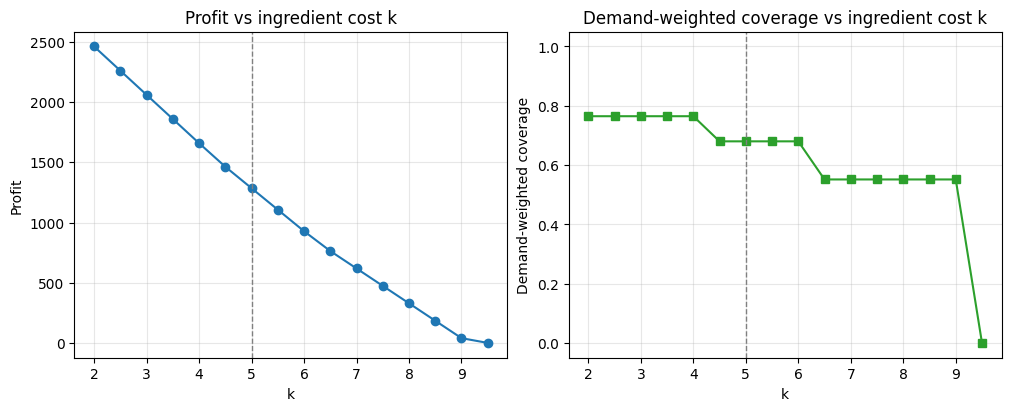

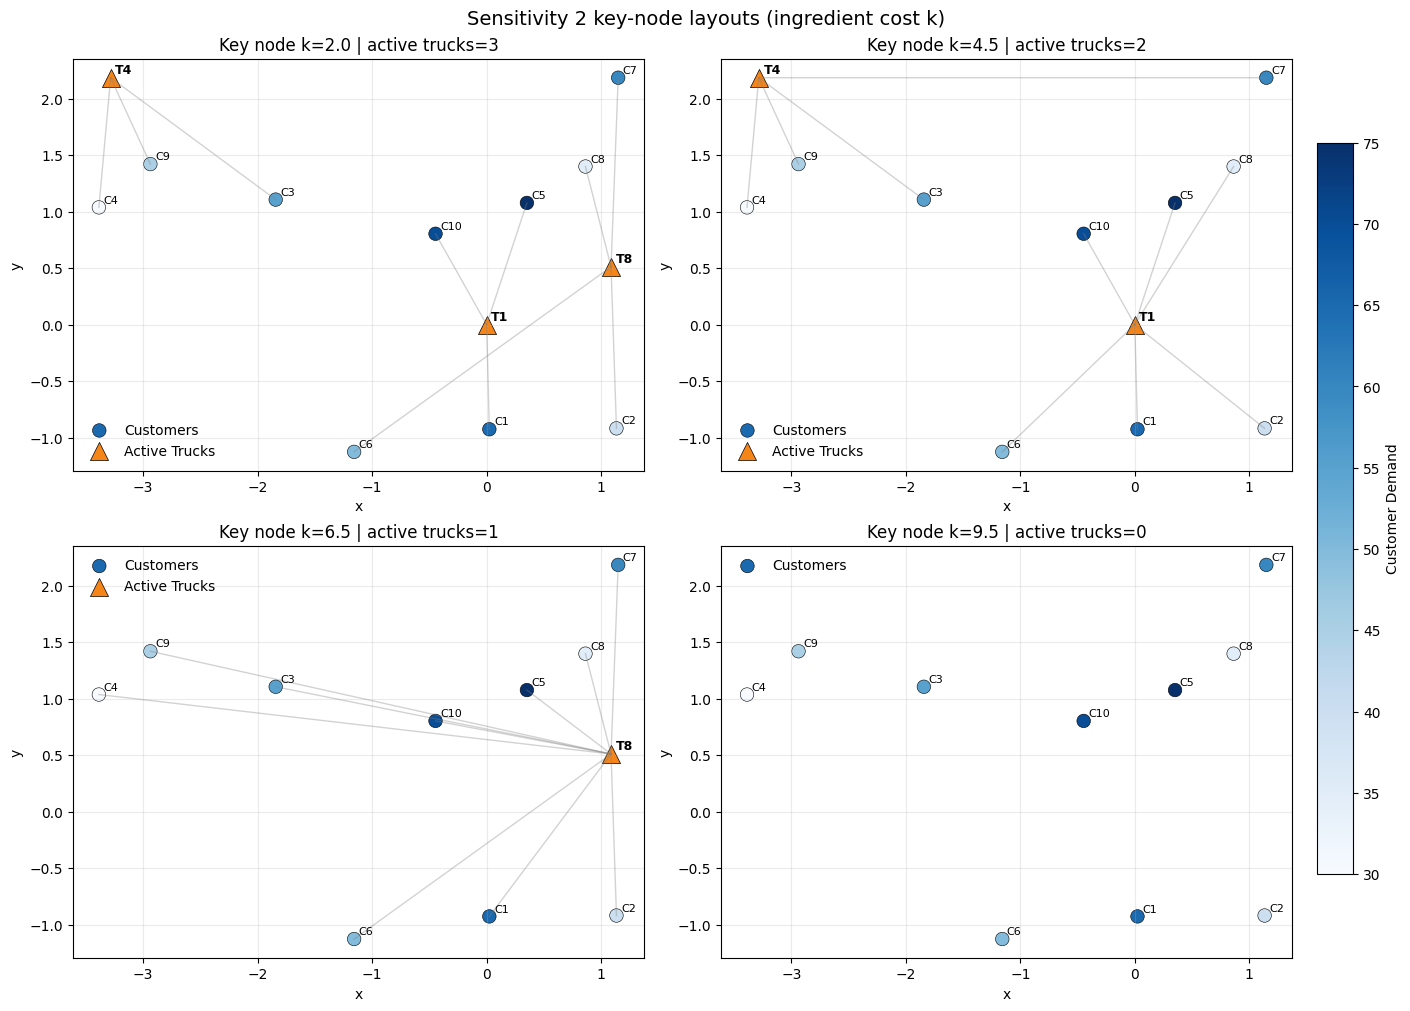

In [20]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

if "solve_basic_model" not in globals():
    raise ValueError("Please run the baseline cell first.")
if "coords_df" not in globals():
    raise ValueError("Please run the inverse-coordinate cell first to get coords_df.")
if "baseline_summary" not in globals() or "baseline_assignment" not in globals():
    raise ValueError("Please run the baseline-solution cell first.")

# Scan ingredient cost around baseline k=5
k_grid = np.arange(2.0, 9.51, 0.5)
records_k = []
coverage_matrix = []
solution_cache_k = {}
assignment_signature = {}
prev_signature = None
key_k_nodes = []

for k_test in k_grid:
    summary_tmp, assign_tmp, _ = solve_basic_model(
        r=r,
        k=float(k_test),
        f=f,
        demands=demands,
        alpha=alpha,
        unavailable_customers=None,
    )

    coverage_map = assign_tmp.set_index("customer")["coverage_alpha"].to_dict()
    row = [coverage_map[c] for c in customers]
    coverage_matrix.append(row)

    records_k.append({
        "k": float(k_test),
        "profit": summary_tmp["objective_profit"],
        "n_open_sites": summary_tmp["n_open_sites"],
        "open_sites": ", ".join(summary_tmp["open_sites"]),
        "service_coverage": summary_tmp["service_coverage"],
    })

    solution_cache_k[float(k_test)] = (summary_tmp, assign_tmp)
    sig = tuple(assign_tmp.set_index("customer").loc[customers, "assigned_site"].tolist())
    assignment_signature[float(k_test)] = sig
    if prev_signature is None or sig != prev_signature:
        key_k_nodes.append(float(k_test))
    prev_signature = sig

df_k_sens = pd.DataFrame(records_k)
coverage_status_df = pd.DataFrame(coverage_matrix, columns=customers)
coverage_status_df.insert(0, "k", k_grid)

display(df_k_sens)
print("\nCustomer coverage-alpha table (alpha if served, 0 if unserved):")
display(coverage_status_df)

# Resilience index: max k where customer still has positive coverage
resilience_rows = []
for c in customers:
    positive_ks = coverage_status_df.loc[coverage_status_df[c] > 0, "k"]
    resilience_k = float(positive_ks.max()) if len(positive_ks) > 0 else np.nan
    resilience_rows.append({"customer": c, "resilience_k_max": resilience_k})
df_resilience = pd.DataFrame(resilience_rows).sort_values("resilience_k_max", ascending=False)

print("\nCustomer resilience index (higher means positive coverage under higher k):")
display(df_resilience)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].plot(df_k_sens["k"], df_k_sens["profit"], marker="o", color="#1f77b4")
axes[0].axvline(5.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Profit vs ingredient cost k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Profit")
axes[0].grid(alpha=0.3)

axes[1].plot(df_k_sens["k"], df_k_sens["service_coverage"], marker="s", color="#2ca02c")
axes[1].axvline(5.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Demand-weighted coverage vs ingredient cost k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Demand-weighted coverage")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.3)

plt.show()

# Spatial plots on key k nodes (same style as previous section)
cust_coords = coords_df[coords_df["type"] == "customer"].set_index("node")[["x", "y"]].to_dict("index")
site_coords = coords_df[coords_df["type"] == "site"].set_index("node")[["x", "y"]].to_dict("index")

# Requirement update: remove k=5.0 key node and remove baseline panel
key_k_values = sorted(set(key_k_nodes))
key_k_values = [kv for kv in key_k_values if kv in solution_cache_k and abs(kv - 5.0) > 1e-9]
if len(key_k_values) == 0:
    key_k_values = [2.0]

# Keep subplot count compact for key nodes
key_k_values = key_k_values[:6]
plot_cases = [{"mode": "k", "value": kv} for kv in key_k_values]

demand_vals = [demands[c] for c in customers]
norm = Normalize(vmin=min(demand_vals), vmax=max(demand_vals))
sm = ScalarMappable(norm=norm, cmap="Blues")
sm.set_array([])

n_s = len(plot_cases)
ncols = 2
nrows = math.ceil(n_s / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, case in enumerate(plot_cases):
    ax = axes[idx]
    k_node = float(case["value"])
    summary_case, assign_case = solution_cache_k[k_node]
    title_tag = f"Key node k={k_node:.1f}"

    xs = [cust_coords[c]["x"] for c in customers]
    ys = [cust_coords[c]["y"] for c in customers]
    demand_now = [demands[c] for c in customers]
    ax.scatter(
        xs, ys, c=demand_now, cmap="Blues", norm=norm,
        s=95, edgecolors="black", linewidths=0.4, label="Customers"
    )

    active_locations = summary_case["open_sites"]
    if active_locations:
        lx = [site_coords[j]["x"] for j in active_locations]
        ly = [site_coords[j]["y"] for j in active_locations]
        ax.scatter(
            lx, ly, marker="^", s=170, c="#F58518",
            edgecolors="black", linewidths=0.5, label="Active Trucks"
        )

    assign_map = assign_case.set_index("customer")["assigned_site"].to_dict()
    for c in customers:
        assigned_loc = assign_map.get(c)
        if assigned_loc is not None and assigned_loc != "unserved":
            x1, y1 = cust_coords[c]["x"], cust_coords[c]["y"]
            x2, y2 = site_coords[assigned_loc]["x"], site_coords[assigned_loc]["y"]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

    for c in customers:
        ax.text(cust_coords[c]["x"] + 0.04, cust_coords[c]["y"] + 0.04, c, fontsize=8)
    for j in active_locations:
        ax.text(site_coords[j]["x"] + 0.04, site_coords[j]["y"] + 0.04, j, fontsize=9, fontweight="bold")

    ax.set_title(f"{title_tag} | active trucks={len(active_locations)}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="best")

for j in range(n_s, len(axes)):
    axes[j].axis("off")

fig.suptitle("Sensitivity 2 key-node layouts (ingredient cost k)", fontsize=14)
fig.colorbar(sm, ax=axes[:n_s], fraction=0.03, pad=0.02, label="Customer Demand")
plt.show()

## Sensitivity 3: High-demand customer unavailable

,removed_customers,removed_total_demand,profit_after_removal,profit_loss,vulnerability_index_pct,open_sites_after_removal,changed_assignments_on_remaining
3,"C5, C10",145,590.0,338.0,36.422414,T8,8
1,C10,70,740.0,188.0,20.258621,T8,9
0,C5,75,758.0,170.0,18.318966,T8,9
2,C1,65,804.0,124.0,13.362069,T8,9



Single-customer vulnerability ranking:


,customer,demand,vulnerability_index_pct
1,C10,70,20.258621
0,C5,75,18.318966
2,C1,65,13.362069


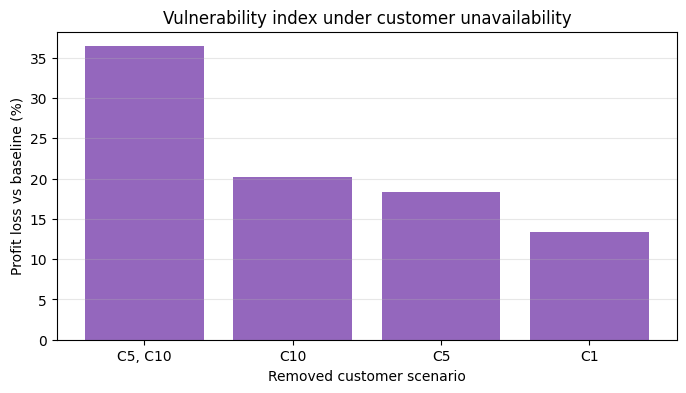

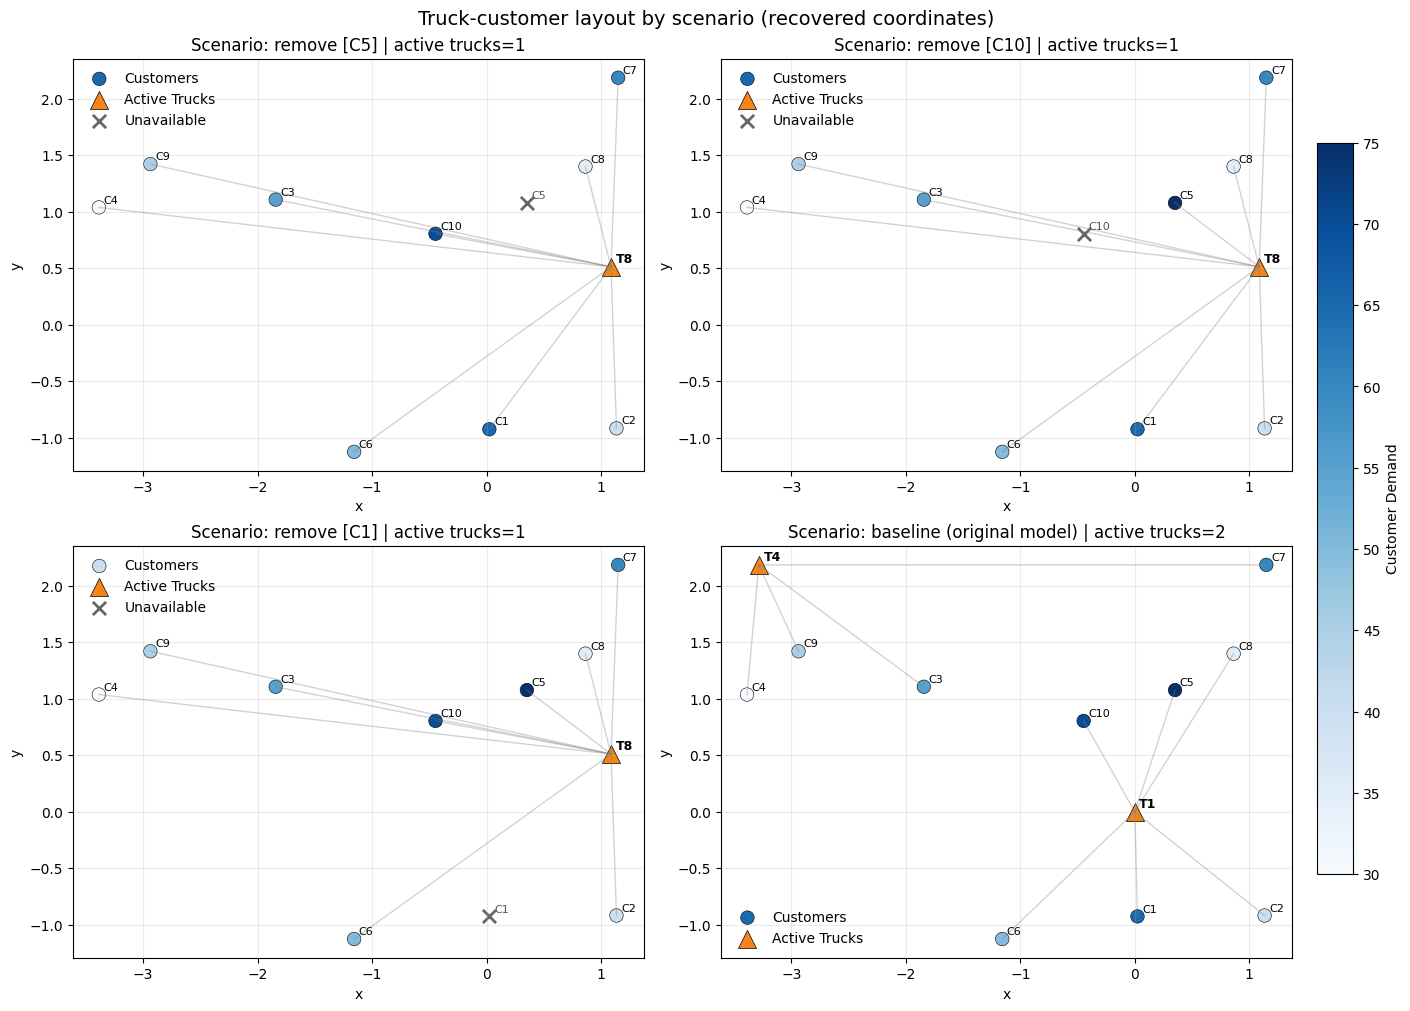

In [21]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

if "solve_basic_model" not in globals() or "baseline_summary" not in globals():
    raise ValueError("Please run the baseline cell first.")
if "coords_df" not in globals():
    raise ValueError("Please run the inverse-coordinate cell first to get coords_df.")

base_profit = baseline_summary["objective_profit"]
base_map = baseline_assignment.set_index("customer")["assigned_site"].to_dict()

# Pick top-demand customers for unavailability scenarios
top_demand_customers = sorted(demands, key=demands.get, reverse=True)[:3]
scenarios = [[c] for c in top_demand_customers]
scenarios.append(top_demand_customers[:2])  # combined outage of top 2

rows = []
for removed in scenarios:
    summary_tmp, assign_tmp, _ = solve_basic_model(
        r=r,
        k=k,
        f=f,
        demands=demands,
        alpha=alpha,
        unavailable_customers=removed,
    )

    new_profit = summary_tmp["objective_profit"]
    profit_loss = base_profit - new_profit
    loss_pct = (profit_loss / base_profit) * 100 if base_profit != 0 else 0.0

    remaining = [c for c in customers if c not in removed]
    new_map = assign_tmp.set_index("customer")["assigned_site"].to_dict()
    changed_remaining = sum(1 for c in remaining if base_map.get(c) != new_map.get(c))

    rows.append({
        "removed_customers": ", ".join(removed),
        "removed_total_demand": sum(demands[c] for c in removed),
        "profit_after_removal": new_profit,
        "profit_loss": profit_loss,
        "vulnerability_index_pct": loss_pct,
        "open_sites_after_removal": ", ".join(summary_tmp["open_sites"]),
        "changed_assignments_on_remaining": changed_remaining,
    })

df_unavailable = pd.DataFrame(rows).sort_values("vulnerability_index_pct", ascending=False)
display(df_unavailable)

# Single-customer vulnerability ranking
single_rows = []
for c in top_demand_customers:
    single_loss_pct = float(df_unavailable.loc[df_unavailable["removed_customers"] == c, "vulnerability_index_pct"].iloc[0])
    single_rows.append({"customer": c, "demand": demands[c], "vulnerability_index_pct": single_loss_pct})
df_vulnerability = pd.DataFrame(single_rows).sort_values("vulnerability_index_pct", ascending=False)

print("\nSingle-customer vulnerability ranking:")
display(df_vulnerability)

plt.figure(figsize=(8, 4))
plt.bar(df_unavailable["removed_customers"], df_unavailable["vulnerability_index_pct"], color="#9467bd")
plt.title("Vulnerability index under customer unavailability")
plt.xlabel("Removed customer scenario")
plt.ylabel("Profit loss vs baseline (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Spatial plots in the style of model_with_fig.ipynb
cust_coords = coords_df[coords_df["type"] == "customer"].set_index("node")[["x", "y"]].to_dict("index")
site_coords = coords_df[coords_df["type"] == "site"].set_index("node")[["x", "y"]].to_dict("index")

# Replace the combined [C5, C10] panel with the original baseline panel
plot_cases = [
    {"removed": [top_demand_customers[0]], "title": f"Scenario: remove [{top_demand_customers[0]}]"},
    {"removed": [top_demand_customers[1]], "title": f"Scenario: remove [{top_demand_customers[1]}]"},
    {"removed": [top_demand_customers[2]], "title": f"Scenario: remove [{top_demand_customers[2]}]"},
    {"removed": [], "title": "Scenario: baseline (original model)"},
]

n_s = len(plot_cases)
ncols = 2
nrows = math.ceil(n_s / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

demand_vals = [demands[c] for c in customers]
norm = Normalize(vmin=min(demand_vals), vmax=max(demand_vals))
sm = ScalarMappable(norm=norm, cmap="Blues")
sm.set_array([])

for idx, case in enumerate(plot_cases):
    ax = axes[idx]
    removed = case["removed"]
    summary_case, assign_case, _ = solve_basic_model(
        r=r,
        k=k,
        f=f,
        demands=demands,
        alpha=alpha,
        unavailable_customers=removed,
    )

    active_customers = [c for c in customers if c not in removed]
    demand_active = [demands[c] for c in active_customers]
    xs = [cust_coords[c]["x"] for c in active_customers]
    ys = [cust_coords[c]["y"] for c in active_customers]
    sc = ax.scatter(
        xs, ys, c=demand_active, cmap="Blues", norm=norm,
        s=95, edgecolors="black", linewidths=0.4, label="Customers"
    )

    active_locations = summary_case["open_sites"]
    if active_locations:
        lx = [site_coords[j]["x"] for j in active_locations]
        ly = [site_coords[j]["y"] for j in active_locations]
        ax.scatter(
            lx, ly, marker="^", s=170, c="#F58518",
            edgecolors="black", linewidths=0.5, label="Active Trucks"
        )

    removed_set = set(removed)
    if removed:
        rx = [cust_coords[c]["x"] for c in removed]
        ry = [cust_coords[c]["y"] for c in removed]
        ax.scatter(rx, ry, marker="x", s=90, c="#666666", linewidths=2.0, label="Unavailable")

    assign_map = assign_case.set_index("customer")["assigned_site"].to_dict()
    for c in active_customers:
        assigned_loc = assign_map.get(c)
        if assigned_loc is not None and assigned_loc != "unserved":
            x1, y1 = cust_coords[c]["x"], cust_coords[c]["y"]
            x2, y2 = site_coords[assigned_loc]["x"], site_coords[assigned_loc]["y"]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

    for c in active_customers:
        ax.text(cust_coords[c]["x"] + 0.04, cust_coords[c]["y"] + 0.04, c, fontsize=8)
    for c in removed:
        ax.text(cust_coords[c]["x"] + 0.04, cust_coords[c]["y"] + 0.04, c, fontsize=8, color="#555555")
    for j in active_locations:
        ax.text(site_coords[j]["x"] + 0.04, site_coords[j]["y"] + 0.04, j, fontsize=9, fontweight="bold")

    ax.set_title(f"{case['title']} | active trucks={len(active_locations)}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="best")

for j in range(n_s, len(axes)):
    axes[j].axis("off")

fig.suptitle("Truck-customer layout by scenario (recovered coordinates)", fontsize=14)
fig.colorbar(sm, ax=axes[:n_s], fraction=0.03, pad=0.02, label="Customer Demand")
plt.show()

## Sensitivity 4: Customer Demand Scaling

,scale_s,profit,profit_change_pct_vs_baseline,n_open_sites,delta_open_sites_vs_baseline,service_coverage,coverage_change_pct_vs_baseline,changed_assignments_vs_baseline,open_sites
0,0.5,329.0,-6.454741e+01,1,-1,0.551429,-1.890756e+01,10,T8
1,0.6,444.8,-5.206897e+01,1,-1,0.551429,-1.890756e+01,10,T8
2,0.7,560.6,-3.959052e+01,1,-1,0.551429,-1.890756e+01,10,T8
3,0.8,676.4,-2.711207e+01,1,-1,0.551429,-1.890756e+01,10,T8
4,0.9,792.2,-1.463362e+01,1,-1,0.551429,-1.890756e+01,10,T8
5,1.0,928.0,-2.450147e-14,2,0,0.680000,0.000000e+00,0,"T1, T4"
6,1.1,1070.8,1.538793e+01,2,0,0.680000,0.000000e+00,0,"T1, T4"
7,1.2,1213.6,3.077586e+01,2,0,0.680000,-1.632681e-14,0,"T1, T4"
8,1.3,1356.4,4.616379e+01,2,0,0.680000,-1.632681e-14,0,"T1, T4"
9,1.4,1499.2,6.155172e+01,2,0,0.680000,0.000000e+00,0,"T1, T4"



Threshold points (open-site count changed):


,scale_s,n_open_sites,profit
5,1.0,2,928.0
10,1.5,3,1659.0


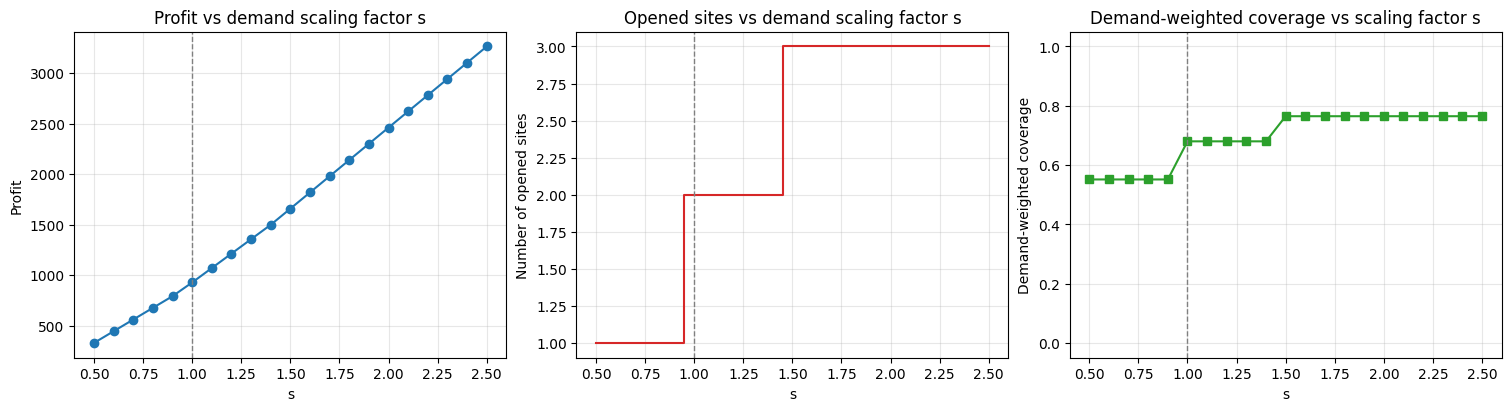

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "solve_basic_model" not in globals():
    raise ValueError("Please run the baseline cell first.")
if "baseline_summary" not in globals() or "baseline_assignment" not in globals():
    raise ValueError("Please run the baseline-solution cell first.")
if "demands" not in globals():
    raise ValueError("Please run the baseline data cell first.")

# 1) Baseline reference
base_profit = float(baseline_summary["objective_profit"])
base_coverage = float(baseline_summary["service_coverage"])
base_open_sites = int(baseline_summary["n_open_sites"])
base_map = baseline_assignment.set_index("customer")["assigned_site"].to_dict()

# 2) Demand scaling factors
scale_grid = np.arange(0.5, 2.51, 0.1)  # 0.8, 0.9, 1.0, 1.1, 1.2

records_s = []
solution_cache_s = {}

for s in scale_grid:
    # Scale all customer demands by s
    demands_scaled = {c: float(demands[c]) * float(s) for c in customers}

    summary_tmp, assign_tmp, _ = solve_basic_model(
        r=r,
        k=k,
        f=f,
        demands=demands_scaled,
        alpha=alpha,
        unavailable_customers=None,
    )

    new_map = assign_tmp.set_index("customer")["assigned_site"].to_dict()
    changed_assignments = sum(1 for c in base_map if base_map[c] != new_map.get(c))

    profit_tmp = float(summary_tmp["objective_profit"])
    coverage_tmp = float(summary_tmp["service_coverage"])
    open_tmp = int(summary_tmp["n_open_sites"])

    profit_change_pct = ((profit_tmp - base_profit) / abs(base_profit) * 100.0) if base_profit != 0 else np.nan
    coverage_change_pct = ((coverage_tmp - base_coverage) / abs(base_coverage) * 100.0) if base_coverage != 0 else np.nan

    records_s.append({
        "scale_s": float(s),
        "profit": profit_tmp,
        "profit_change_pct_vs_baseline": profit_change_pct,
        "n_open_sites": open_tmp,
        "delta_open_sites_vs_baseline": open_tmp - base_open_sites,
        "service_coverage": coverage_tmp,
        "coverage_change_pct_vs_baseline": coverage_change_pct,
        "changed_assignments_vs_baseline": int(changed_assignments),
        "open_sites": ", ".join(summary_tmp["open_sites"]),
    })

    solution_cache_s[float(s)] = (summary_tmp, assign_tmp)

df_demand_sens = pd.DataFrame(records_s)
display(df_demand_sens)

# 3) Optional: identify structure-change key nodes
df_demand_sens["delta_open_sites_step"] = df_demand_sens["n_open_sites"].diff().fillna(0)
threshold_s = df_demand_sens[df_demand_sens["delta_open_sites_step"] != 0][["scale_s", "n_open_sites", "profit"]]

print("\nThreshold points (open-site count changed):")
if len(threshold_s) == 0:
    print("No open-site count change in this scale range.")
else:
    display(threshold_s)

# 4) Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].plot(df_demand_sens["scale_s"], df_demand_sens["profit"], marker="o", color="#1f77b4")
axes[0].axvline(1.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Profit vs demand scaling factor s")
axes[0].set_xlabel("s")
axes[0].set_ylabel("Profit")
axes[0].grid(alpha=0.3)

axes[1].step(df_demand_sens["scale_s"], df_demand_sens["n_open_sites"], where="mid", color="#d62728")
axes[1].axvline(1.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Opened sites vs demand scaling factor s")
axes[1].set_xlabel("s")
axes[1].set_ylabel("Number of opened sites")
axes[1].grid(alpha=0.3)

axes[2].plot(df_demand_sens["scale_s"], df_demand_sens["service_coverage"], marker="s", color="#2ca02c")
axes[2].axvline(1.0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Demand-weighted coverage vs scaling factor s")
axes[2].set_xlabel("s")
axes[2].set_ylabel("Demand-weighted coverage")
axes[2].set_ylim(-0.05, 1.05)
axes[2].grid(alpha=0.3)

plt.show()

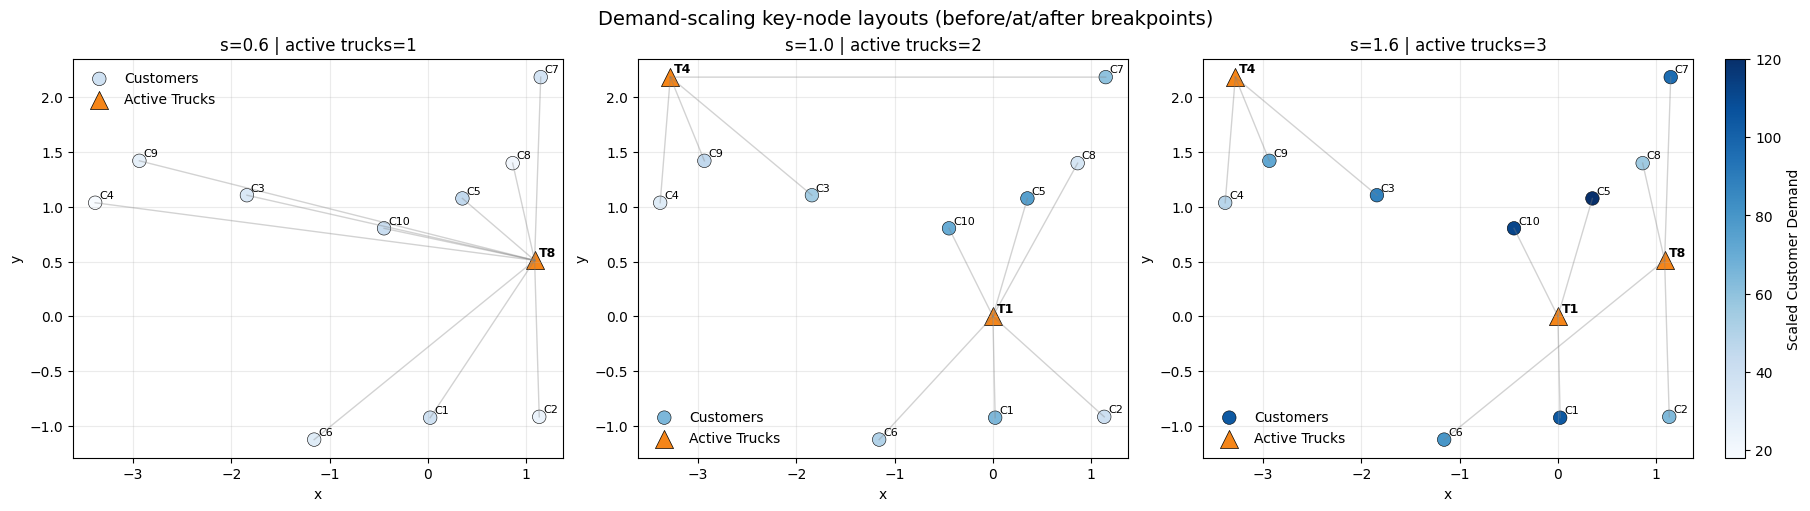

In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

if "solution_cache_s" not in globals():
    raise ValueError("Please run the demand-scaling sensitivity cell first.")
if "coords_df" not in globals():
    raise ValueError("Please run the inverse-coordinate cell first to get coords_df.")

# 坐标映射
cust_coords = coords_df[coords_df["type"] == "customer"].set_index("node")[["x", "y"]].to_dict("index")
site_coords = coords_df[coords_df["type"] == "site"].set_index("node")[["x", "y"]].to_dict("index")

# 根据你当前结果，手动指定关键节点前后窗口
target_scales = [0.6, 1.0, 1.6]

# 防止浮点误差：映射到缓存中真实存在的 s
existing_scales = np.array(sorted(float(s) for s in solution_cache_s.keys()), dtype=float)

def snap_scale(v):
    idx = int(np.argmin(np.abs(existing_scales - v)))
    if abs(existing_scales[idx] - v) > 1e-8:
        return None
    return float(existing_scales[idx])

plot_scales = []
for v in target_scales:
    sv = snap_scale(v)
    if sv is not None:
        plot_scales.append(sv)

plot_scales = sorted(set(plot_scales))
if len(plot_scales) == 0:
    raise ValueError("No valid key scales found in solution_cache_s.")

# 颜色范围：按本次展示的 s 范围统一，便于横向比较
s_min, s_max = min(plot_scales), max(plot_scales)
demand_min = min(demands[c] * s_min for c in customers)
demand_max = max(demands[c] * s_max for c in customers)
norm = Normalize(vmin=demand_min, vmax=demand_max)
sm = ScalarMappable(norm=norm, cmap="Blues")
sm.set_array([])

# 子图布局
n_s = len(plot_scales)
ncols = 3
nrows = math.ceil(n_s / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, s_node in enumerate(plot_scales):
    ax = axes[idx]
    summary_case, assign_case = solution_cache_s[float(s_node)]

    # 当前 s 的需求
    demands_scaled = {c: float(demands[c]) * float(s_node) for c in customers}

    # 顾客点
    xs = [cust_coords[c]["x"] for c in customers]
    ys = [cust_coords[c]["y"] for c in customers]
    demand_now = [demands_scaled[c] for c in customers]
    ax.scatter(
        xs, ys, c=demand_now, cmap="Blues", norm=norm,
        s=95, edgecolors="black", linewidths=0.4, label="Customers"
    )

    # 启用车辆
    active_locations = summary_case["open_sites"]
    if active_locations:
        lx = [site_coords[j]["x"] for j in active_locations]
        ly = [site_coords[j]["y"] for j in active_locations]
        ax.scatter(
            lx, ly, marker="^", s=170, c="#F58518",
            edgecolors="black", linewidths=0.5, label="Active Trucks"
        )

    # 连线
    assign_map = assign_case.set_index("customer")["assigned_site"].to_dict()
    for c in customers:
        assigned_loc = assign_map.get(c)
        if assigned_loc is not None and assigned_loc != "unserved":
            x1, y1 = cust_coords[c]["x"], cust_coords[c]["y"]
            x2, y2 = site_coords[assigned_loc]["x"], site_coords[assigned_loc]["y"]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

    # 标注
    for c in customers:
        ax.text(cust_coords[c]["x"] + 0.04, cust_coords[c]["y"] + 0.04, c, fontsize=8)
    for j in active_locations:
        ax.text(site_coords[j]["x"] + 0.04, site_coords[j]["y"] + 0.04, j, fontsize=9, fontweight="bold")

    ax.set_title(f"s={s_node:.1f} | active trucks={len(active_locations)}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="best")

for j in range(n_s, len(axes)):
    axes[j].axis("off")

fig.suptitle("Demand-scaling key-node layouts (before/at/after breakpoints)", fontsize=14)
fig.colorbar(sm, ax=axes[:n_s], fraction=0.03, pad=0.02, label="Scaled Customer Demand")
plt.show()